# Pharmaceutical Sales Analysis
This notebook analyzes the pharmaceutical sales dataset and answers the project questions.

## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [3]:
df = pd.read_csv('Data/salesdaily.csv')
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


## 3. Initial Data Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


In [5]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='object')

## 4. Data Preparation
Convert the date column to datetime format for time-based analysis.

In [6]:
df['datum'] = pd.to_datetime(df['datum'])
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


## 5. Define ATC Categories
These columns represent the medication categories used in the analysis.

In [7]:
atc_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
atc_columns

['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

## Task 1: Total Sales by ATC Category
This section calculates the total sales for each ATC category.

In [8]:
total_sales = df[atc_columns].sum().round(2).sort_values(ascending=False)
total_sales

N02BE    63005.40
N05B     18645.74
R03      11608.82
M01AB    10600.94
M01AE     8204.62
N02BA     8172.21
R06       6107.82
N05C      1249.96
dtype: float64

### 1. Graph of Task 1

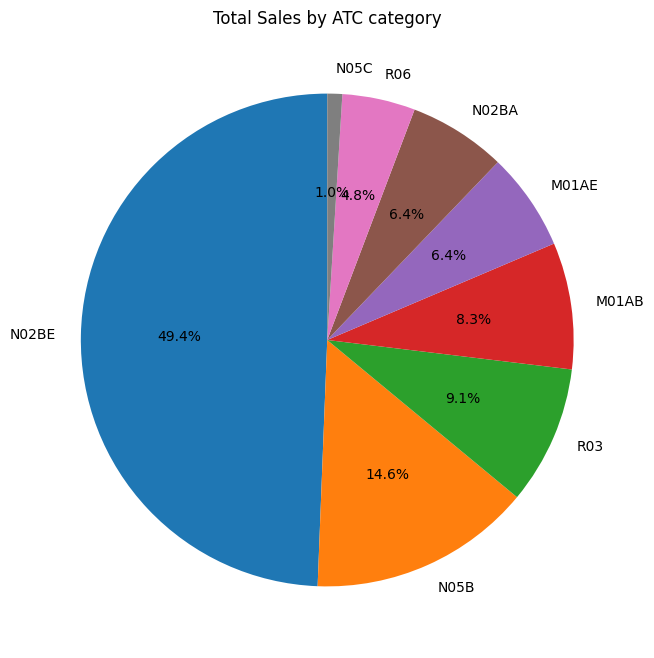

In [9]:
from matplotlib.pyplot import autoscale, pie


total_sales.plot(
    kind = 'pie',
    autopct = '%1.1f%%',
    figsize = (8,8),
    startangle = 90
)

plt.ylabel('')
plt.title('Total Sales by ATC category')
plt.show()

### Conclusion task 1
N02BE has the highest total sales volume, followed by N05B and R03.

## Task 2: Brands with the highest sales volume.

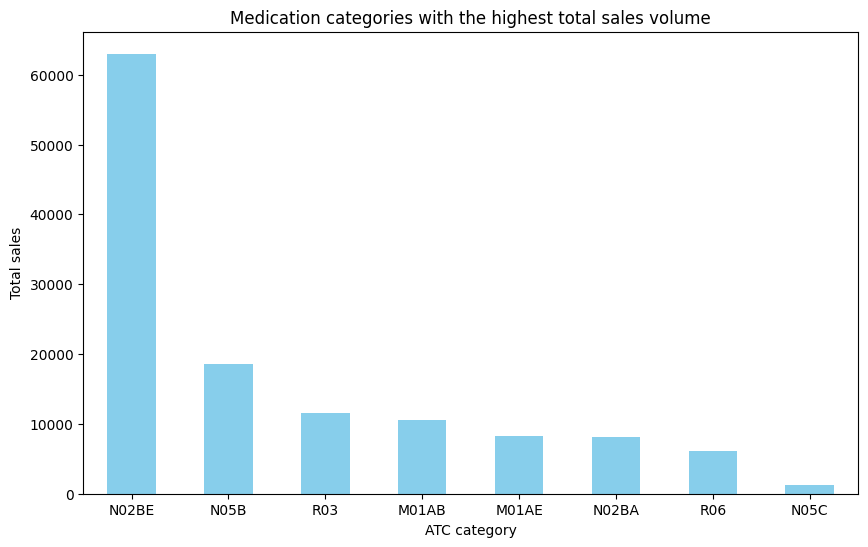

In [10]:
total_sales.plot(
    kind = 'bar',
    figsize = (10,6),
    color = 'skyblue'
)

plt.title('Medication categories with the highest total sales volume')
plt.xlabel('ATC category')
plt.ylabel('Total sales')
plt.xticks(rotation=0)
plt.show()

### Conclusion task 2
N02BE shows the highest total sales volume, followed by N05B and R03.

## Task 3: Top 3 medications for January 2015, July 2016, and September 2017.

In [11]:
jan_2015 = df[(df['Year'] == 2015) & (df['Month'] == 1)]
jan_2015_top3 = jan_2015[atc_columns].sum().round(2).sort_values(ascending=False).head(3)
jan_2015_top3

N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

In [12]:
jul_2016 = df[(df['Year'] == 2016) & (df['Month'] == 7)]
jul_2016_top3 = jul_2016[atc_columns].sum().round(2).sort_values(ascending=False).head(3)
jul_2016_top3

N02BE    652.36
N05B     240.00
M01AB    194.53
dtype: float64

In [13]:
sep_2017 = df[(df['Year'] == 2017) & (df['Month'] == 9)]
sep_2017_top3 = sep_2017[atc_columns].sum().round(2).sort_values(ascending=False).head(3)
sep_2017_top3

N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64

### 1. graph of top 3  medications for january 2015

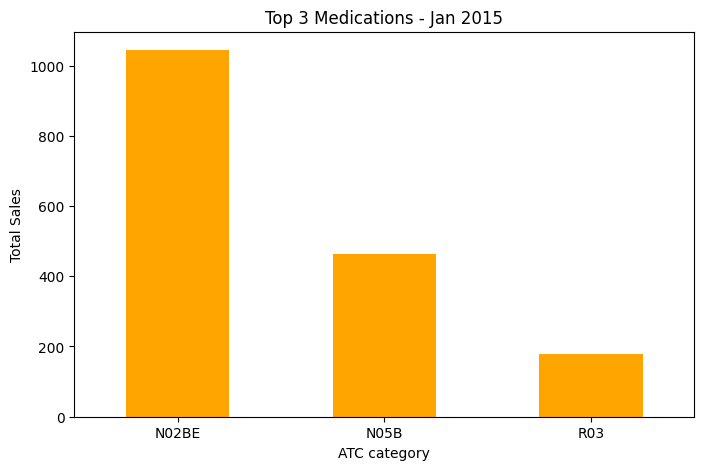

In [14]:
jan_2015_top3.plot(
    kind = 'bar',
    color = 'orange',
    figsize = (8,5)
)

plt.title('Top 3 Medications - Jan 2015')
plt.xlabel('ATC category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### 2. graph of top 3 medicarions for July 2016

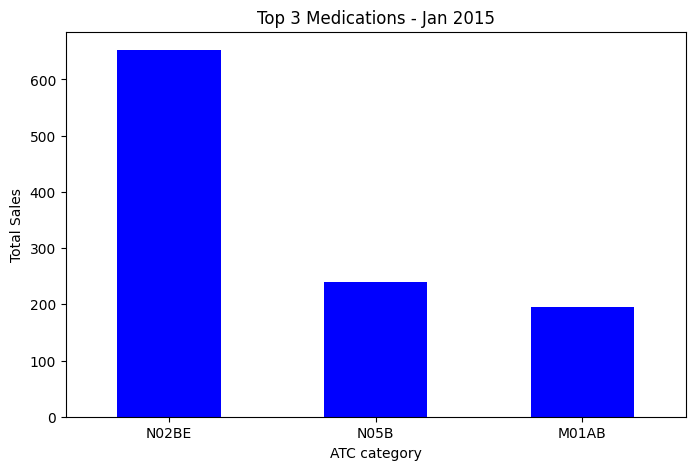

In [15]:
jul_2016_top3.plot(
    kind = 'bar',
    color = 'blue',
    figsize = (8,5)
)

plt.title('Top 3 Medications - Jan 2015')
plt.xlabel('ATC category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### 3. graph of top 3 medicarions for September 2017

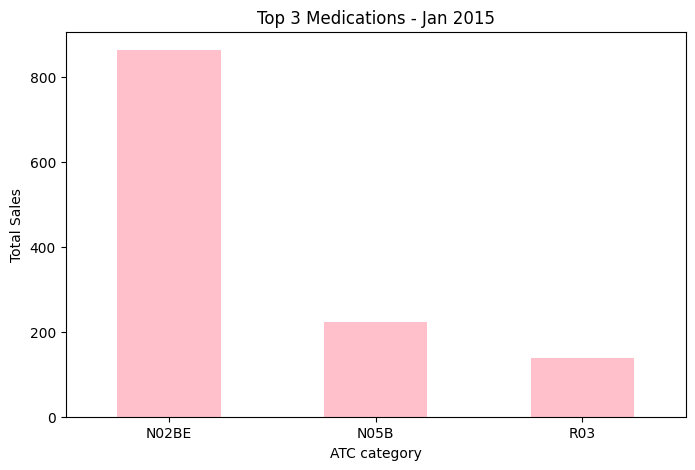

In [16]:
sep_2017_top3.plot(
    kind = 'bar',
    color = 'pink',
    figsize = (8,5)
)

plt.title('Top 3 Medications - Jan 2015')
plt.xlabel('ATC category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### Conclusion task 3
In January 2015, the top 3 categories were N02BE, N05B, and R03.
In July 2016, the top 3 categories were N02BE, N05B, and M01AB.
In September 2017, the top 3 categories were N02BE, N05B, and R03.

## Task 4: Bestsaller in 2017

In [17]:
sales_2017 = df[df['Year'] == 2017][atc_columns].sum().round(2).sort_values(ascending=False)
sales_2017

N02BE    9258.80
N05B     2555.54
R03      1893.61
M01AB    1846.62
M01AE    1387.30
N02BA    1288.30
R06       988.86
N05C      180.33
dtype: float64

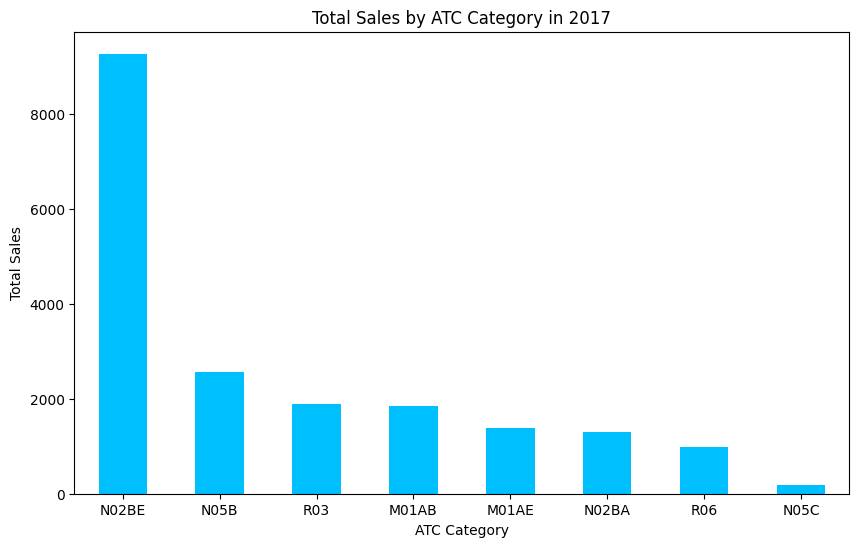

In [18]:
sales_2017.plot(
    kind = 'bar',
    figsize = (10,6),
    color = 'deepskyblue'
)

plt.title('Total Sales by ATC Category in 2017')
plt.xlabel('ATC Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.show()

### Conclusion task 4
the bestsaler in 2017 is the N02BE

## Task 5: Highest average daily sales in the pharmaceutical category.

In [19]:
average_daily_sales = df[atc_columns].mean().round(2).sort_values(ascending=False)
average_daily_sales

N02BE    29.92
N05B      8.85
R03       5.51
M01AB     5.03
M01AE     3.90
N02BA     3.88
R06       2.90
N05C      0.59
dtype: float64

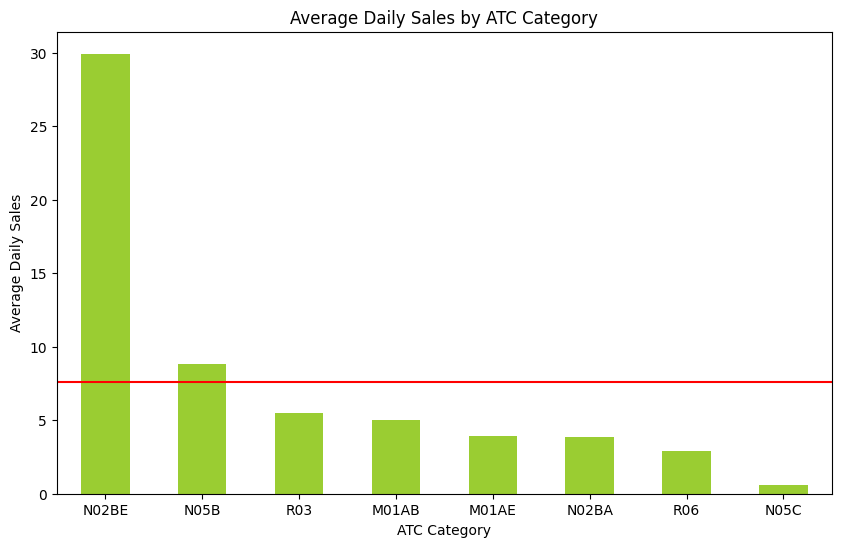

In [20]:
average_daily_sales.plot(
    kind = 'bar',
    figsize = (10,6),
    color = 'yellowgreen'
)

plt.axhline(
    average_daily_sales.mean(),
    color='red',
    linestyle='-',
    label='Overall Average'
)

plt.title('Average Daily Sales by ATC Category')
plt.xlabel('ATC Category')
plt.ylabel('Average Daily Sales')
plt.xticks(rotation=0)
plt.show()

### Conclusion task 5
N02BE has the highest average daily sales among all ATC categories.

## task 6: average of R03 medicines sold per month

In [26]:
r03_mean_month = df.groupby('Month')['R03'].mean().round(2)
r03_mean_month

Month
1     6.84
2     6.90
3     6.29
4     5.77
5     5.01
6     4.35
7     2.96
8     3.10
9     4.40
10    7.21
11    6.23
12    7.92
Name: R03, dtype: float64

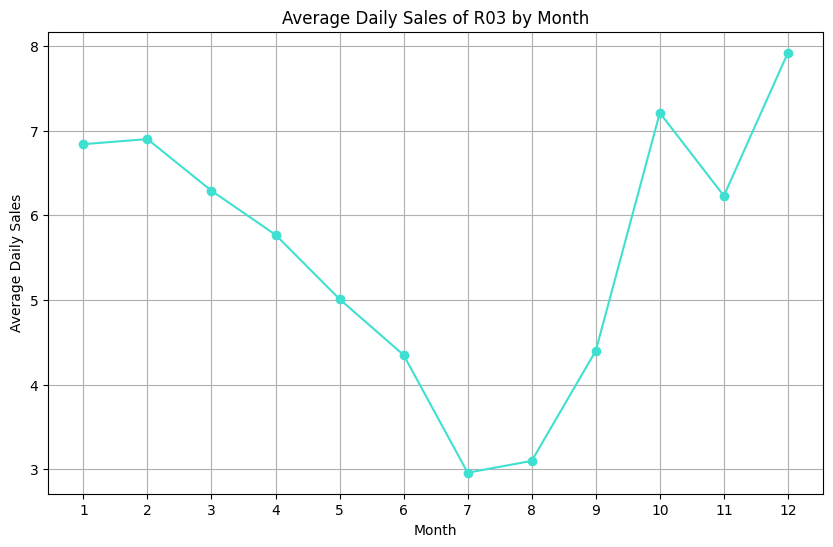

In [27]:
r03_mean_month.plot(
    kind = 'line',
    marker = 'o',
    figsize = (10,6),
    color = 'turquoise'
)

plt.title('Average Daily Sales of R03 by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Sales')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

### Conclusion task 6
R03 shows a clear seasonal pattern throughout the year. Sales increase in certain months and decline in others, suggesting that demand for respiratory medications is not evenly distributed over time and may be associated with seasonal factors.